# Correct-answer ROC AUC dynamics

This notebook tracks how well the student's single-token answer entropy separates correct from incorrect MMLU answers over training. A correct answer is the positive class, and negative entropy is used as the score so that lower entropy means greater estimated likelihood of correctness.

The comparison includes the three entropy-based strategies that re-estimate complexity every epoch: `entropy_gain`, `entropy_gain_proportional`, and `student_entropy`. One-shot and random-estimator runs are intentionally excluded because they cannot provide entropy ROC AUC dynamics.

Two complexity scores are analyzed: student entropy and entropy gain. The experiment constructs proxy teacher entropy by averaging the normalized Llama 70B and Qwen 72B entropies; the sampler then defines entropy gain as `max(student_entropy - teacher_entropy, 0)`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.metrics import roc_auc_score

for directory in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    source_dir = directory / "src"
    if (source_dir / "core").is_dir():
        sys.path.insert(0, str(source_dir))
        break
else:
    raise FileNotFoundError("Could not find the repository's src/core directory")

from core.utils.graph_style import set_style

set_style()

ARTIFACT_GROUP = "distillation_by_metrics/mmlu"
EXPERIMENTS = ("entropy_gain", "entropy_gain_proportional", "student_entropy")
SCORE_COLUMN = "entropy_value"
TEACHER_ENTROPY_COLUMN = "teacher_entropy"
CORRECTNESS_COLUMN = "estimation_phase_answer_correctness"
EXPECTED_EPOCHS = set(range(100))
TOP_K_SUBSETS = (1024, 2048)

EXPERIMENT_LABELS = {
    "entropy_gain": "Entropy gain",
    "entropy_gain_proportional": "Entropy gain proportional",
    "student_entropy": "Student entropy",
}
MODEL_LABELS = {
    "llama_3b_head_truncated8192": "Llama 3B",
    "phi4_mini_head_truncated8192": "Phi-4 Mini",
    "qwen_3b_head_truncated8192": "Qwen 3B",
}

In [2]:
def find_artifacts_dir(start: Path | None = None) -> Path:
    """Walk upward from the current directory until artifacts/ is found."""
    start = (start or Path.cwd()).resolve()
    for directory in (start, *start.parents):
        candidate = directory / "artifacts"
        if candidate.is_dir():
            return candidate
    raise FileNotFoundError(f"Could not find artifacts/ above {start}")


def load_roc_auc_dynamics(group_dir: Path) -> tuple[pd.DataFrame, pd.DataFrame, list[str]]:
    """Load every selected run/epoch and calculate ROC AUC for a correct answer."""
    records = []
    subset_records = []
    skipped = []

    for experiment in EXPERIMENTS:
        experiment_dir = group_dir / experiment
        if not experiment_dir.is_dir():
            raise FileNotFoundError(f"Missing experiment directory: {experiment_dir}")

        for model_dir in sorted(path for path in experiment_dir.iterdir() if path.is_dir()):
            parquet_paths = sorted(
                model_dir.glob("resampling_trainer_data/*/complexity_estimation/*.parquet"),
                key=lambda path: int(path.parents[1].name),
            )
            for parquet_path in parquet_paths:
                epoch = int(parquet_path.parents[1].name)
                epoch_df = pd.read_parquet(
                    parquet_path,
                    columns=[CORRECTNESS_COLUMN, SCORE_COLUMN, TEACHER_ENTROPY_COLUMN],
                ).dropna(subset=[CORRECTNESS_COLUMN, SCORE_COLUMN, TEACHER_ENTROPY_COLUMN])

                if epoch_df.empty:
                    skipped.append(f"{experiment}/{model_dir.name}/epoch {epoch}: no valid rows")
                    continue

                answer_correct = epoch_df[CORRECTNESS_COLUMN].astype(bool).astype(int)
                correctness_score = -epoch_df[SCORE_COLUMN]
                entropy_gain = (
                    epoch_df[SCORE_COLUMN] - epoch_df[TEACHER_ENTROPY_COLUMN]
                ).clip(lower=0)
                entropy_gain_correctness_score = -entropy_gain
                if answer_correct.nunique() != 2:
                    skipped.append(
                        f"{experiment}/{model_dir.name}/epoch {epoch}: target has one class"
                    )
                    continue

                records.append(
                    {
                        "experiment": experiment,
                        "model": model_dir.name,
                        "epoch": epoch,
                        "roc_auc": roc_auc_score(answer_correct, correctness_score),
                        "entropy_gain_roc_auc": roc_auc_score(
                            answer_correct, entropy_gain_correctness_score
                        ),
                        "num_valid": len(epoch_df),
                        "accuracy": answer_correct.mean(),
                        "target_classes": answer_correct.nunique(),
                    }
                )

                # Analyze exact top-K subsets by the strategy's deterministic complexity proxy.
                # The proportional run uses entropy gain here rather than its stochastic race key.
                selection_score = (
                    epoch_df[SCORE_COLUMN]
                    if experiment == "student_entropy"
                    else entropy_gain
                )
                ranked_df = epoch_df.assign(
                    answer_correct=answer_correct,
                    entropy_gain=entropy_gain,
                    selection_score=selection_score,
                ).sort_values("selection_score", ascending=False, kind="stable")
                for top_k in TOP_K_SUBSETS:
                    selected = ranked_df.head(top_k)
                    if selected["answer_correct"].nunique() != 2:
                        skipped.append(
                            f"{experiment}/{model_dir.name}/epoch {epoch}/top {top_k}: "
                            "target has one class"
                        )
                        continue
                    subset_records.append(
                        {
                            "experiment": experiment,
                            "model": model_dir.name,
                            "epoch": epoch,
                            "subset_size": top_k,
                            "num_selected": len(selected),
                            "roc_auc": roc_auc_score(
                                selected["answer_correct"], -selected[SCORE_COLUMN]
                            ),
                            "entropy_gain_roc_auc": roc_auc_score(
                                selected["answer_correct"], -selected["entropy_gain"]
                            ),
                            "target_classes": selected["answer_correct"].nunique(),
                        }
                    )

    all_rows = pd.DataFrame.from_records(records).sort_values(
        ["model", "experiment", "epoch"]
    ).reset_index(drop=True)
    top_rows = pd.DataFrame.from_records(subset_records).sort_values(
        ["subset_size", "model", "experiment", "epoch"]
    ).reset_index(drop=True)
    return all_rows, top_rows, skipped


ARTIFACTS_DIR = find_artifacts_dir()
GROUP_DIR = ARTIFACTS_DIR / ARTIFACT_GROUP
roc_auc_by_epoch, subset_roc_auc_by_epoch, skipped_epochs = load_roc_auc_dynamics(GROUP_DIR)
print(f"Loaded {len(roc_auc_by_epoch):,} epoch metrics from {GROUP_DIR}")
print(f"Calculated {len(subset_roc_auc_by_epoch):,} top-subset metrics")
if skipped_epochs:
    print(f"Skipped {len(skipped_epochs)} invalid epoch(s):")
    print("\n".join(skipped_epochs))

Loaded 900 epoch metrics from /Users/aigoncharov/dev/sktech/recursive_caft/artifacts/distillation_by_metrics/mmlu
Calculated 1,800 top-subset metrics


In [3]:
models = sorted(roc_auc_by_epoch["model"].unique())
expected_runs = {(experiment, model) for experiment in EXPERIMENTS for model in MODEL_LABELS}
observed_runs = set(roc_auc_by_epoch[["experiment", "model"]].itertuples(index=False, name=None))

assert not skipped_epochs, "Every selected epoch should have usable two-class data"
assert set(models) == set(MODEL_LABELS), f"Unexpected models: {models}"
assert observed_runs == expected_runs, f"Unexpected run set: {observed_runs}"
assert len(roc_auc_by_epoch) == len(EXPERIMENTS) * len(MODEL_LABELS) * len(EXPECTED_EPOCHS)
assert pd.api.types.is_integer_dtype(roc_auc_by_epoch["epoch"])
assert roc_auc_by_epoch["roc_auc"].between(0, 1).all()
assert roc_auc_by_epoch["entropy_gain_roc_auc"].between(0, 1).all()
assert roc_auc_by_epoch["num_valid"].gt(0).all()
assert roc_auc_by_epoch["target_classes"].eq(2).all()
for _, run in roc_auc_by_epoch.groupby(["experiment", "model"]):
    assert set(run["epoch"]) == EXPECTED_EPOCHS

expected_subset_rows = (
    len(EXPERIMENTS) * len(MODEL_LABELS) * len(EXPECTED_EPOCHS) * len(TOP_K_SUBSETS)
)
assert len(subset_roc_auc_by_epoch) == expected_subset_rows
assert set(subset_roc_auc_by_epoch["subset_size"]) == set(TOP_K_SUBSETS)
assert subset_roc_auc_by_epoch["num_selected"].eq(
    subset_roc_auc_by_epoch["subset_size"]
).all()
assert subset_roc_auc_by_epoch["roc_auc"].between(0, 1).all()
assert subset_roc_auc_by_epoch["entropy_gain_roc_auc"].between(0, 1).all()
assert subset_roc_auc_by_epoch["target_classes"].eq(2).all()
for _, run in subset_roc_auc_by_epoch.groupby(["subset_size", "experiment", "model"]):
    assert set(run["epoch"]) == EXPECTED_EPOCHS

print("Validated 3 models × 3 strategies × 100 complete epochs.")
print("Validated exact top-1,024 and top-2,048 subsets for every run and epoch.")

Validated 3 models × 3 strategies × 100 complete epochs.
Validated exact top-1,024 and top-2,048 subsets for every run and epoch.


In [4]:
summary = (
    roc_auc_by_epoch.sort_values("epoch")
    .groupby(["model", "experiment"], as_index=False)
    .agg(
        initial_roc_auc=("roc_auc", "first"),
        final_roc_auc=("roc_auc", "last"),
        peak_roc_auc=("roc_auc", "max"),
        min_valid_samples=("num_valid", "min"),
    )
)
summary["model"] = summary["model"].map(MODEL_LABELS)
summary["experiment"] = summary["experiment"].map(EXPERIMENT_LABELS)
display(
    summary.rename(
        columns={"model": "Model", "experiment": "Strategy"}
    ).style.format(
        {
            "initial_roc_auc": "{:.3f}",
            "final_roc_auc": "{:.3f}",
            "peak_roc_auc": "{:.3f}",
            "min_valid_samples": "{:,.0f}",
        }
    )
)

,Model,Strategy,initial_roc_auc,final_roc_auc,peak_roc_auc,min_valid_samples
0,Llama 3B,Entropy gain,0.708,0.663,0.785,"9,567"
1,Llama 3B,Entropy gain proportional,0.708,0.846,0.868,"9,610"
2,Llama 3B,Student entropy,0.709,0.473,0.731,"9,623"
3,Phi-4 Mini,Entropy gain,0.732,0.658,0.796,"9,626"
4,Phi-4 Mini,Entropy gain proportional,0.735,0.828,0.871,"9,625"
5,Phi-4 Mini,Student entropy,0.732,0.483,0.763,"9,626"
6,Qwen 3B,Entropy gain,0.711,0.622,0.770,"6,586"
7,Qwen 3B,Entropy gain proportional,0.711,0.872,0.886,"8,381"
8,Qwen 3B,Student entropy,0.710,0.510,0.779,"9,005"


In [5]:
from matplotlib.lines import Line2D

SCORE_LINESTYLES = {
    "roc_auc": ("Student entropy", "-"),
    "entropy_gain_roc_auc": ("Entropy gain", "--"),
}
STRATEGY_COLORS = {
    experiment: plt.get_cmap("tab10")(i)
    for i, experiment in enumerate(EXPERIMENTS)
}

## Entropy-gain proxy and combined comparison

The experiment builds `teacher_entropy` as the row-wise average of normalized Llama 70B and Qwen 72B single-token entropies. Matching `EntropyGainSampler._score_row`, the proxy is calculated without any additional normalization:

```python
entropy_gain = max(entropy_value - teacher_entropy, 0)
```

Correctness is the positive class, so the ROC score is `-entropy_gain`: a smaller gap between student and teacher entropy predicts a correct student answer. The proportional sampler's random race key is deliberately excluded because it controls sampling, not the underlying entropy-gain proxy. The combined plot uses line style for the complexity score and color for the training strategy.

In [6]:
entropy_gain_summary = (
    roc_auc_by_epoch.sort_values("epoch")
    .groupby(["model", "experiment"], as_index=False)
    .agg(
        initial_roc_auc=("entropy_gain_roc_auc", "first"),
        final_roc_auc=("entropy_gain_roc_auc", "last"),
        peak_roc_auc=("entropy_gain_roc_auc", "max"),
        min_valid_samples=("num_valid", "min"),
    )
)
entropy_gain_summary["model"] = entropy_gain_summary["model"].map(MODEL_LABELS)
entropy_gain_summary["experiment"] = entropy_gain_summary["experiment"].map(EXPERIMENT_LABELS)
display(
    entropy_gain_summary.rename(
        columns={"model": "Model", "experiment": "Strategy"}
    ).style.format(
        {
            "initial_roc_auc": "{:.3f}",
            "final_roc_auc": "{:.3f}",
            "peak_roc_auc": "{:.3f}",
            "min_valid_samples": "{:,.0f}",
        }
    )
)

,Model,Strategy,initial_roc_auc,final_roc_auc,peak_roc_auc,min_valid_samples
0,Llama 3B,Entropy gain,0.666,0.378,0.700,"9,567"
1,Llama 3B,Entropy gain proportional,0.667,0.709,0.817,"9,610"
2,Llama 3B,Student entropy,0.668,0.540,0.708,"9,623"
3,Phi-4 Mini,Entropy gain,0.701,0.329,0.720,"9,626"
4,Phi-4 Mini,Entropy gain proportional,0.703,0.597,0.825,"9,625"
5,Phi-4 Mini,Student entropy,0.700,0.507,0.731,"9,626"
6,Qwen 3B,Entropy gain,0.574,0.495,0.697,"6,586"
7,Qwen 3B,Entropy gain proportional,0.573,0.774,0.841,"8,381"
8,Qwen 3B,Student entropy,0.572,0.528,0.728,"9,005"


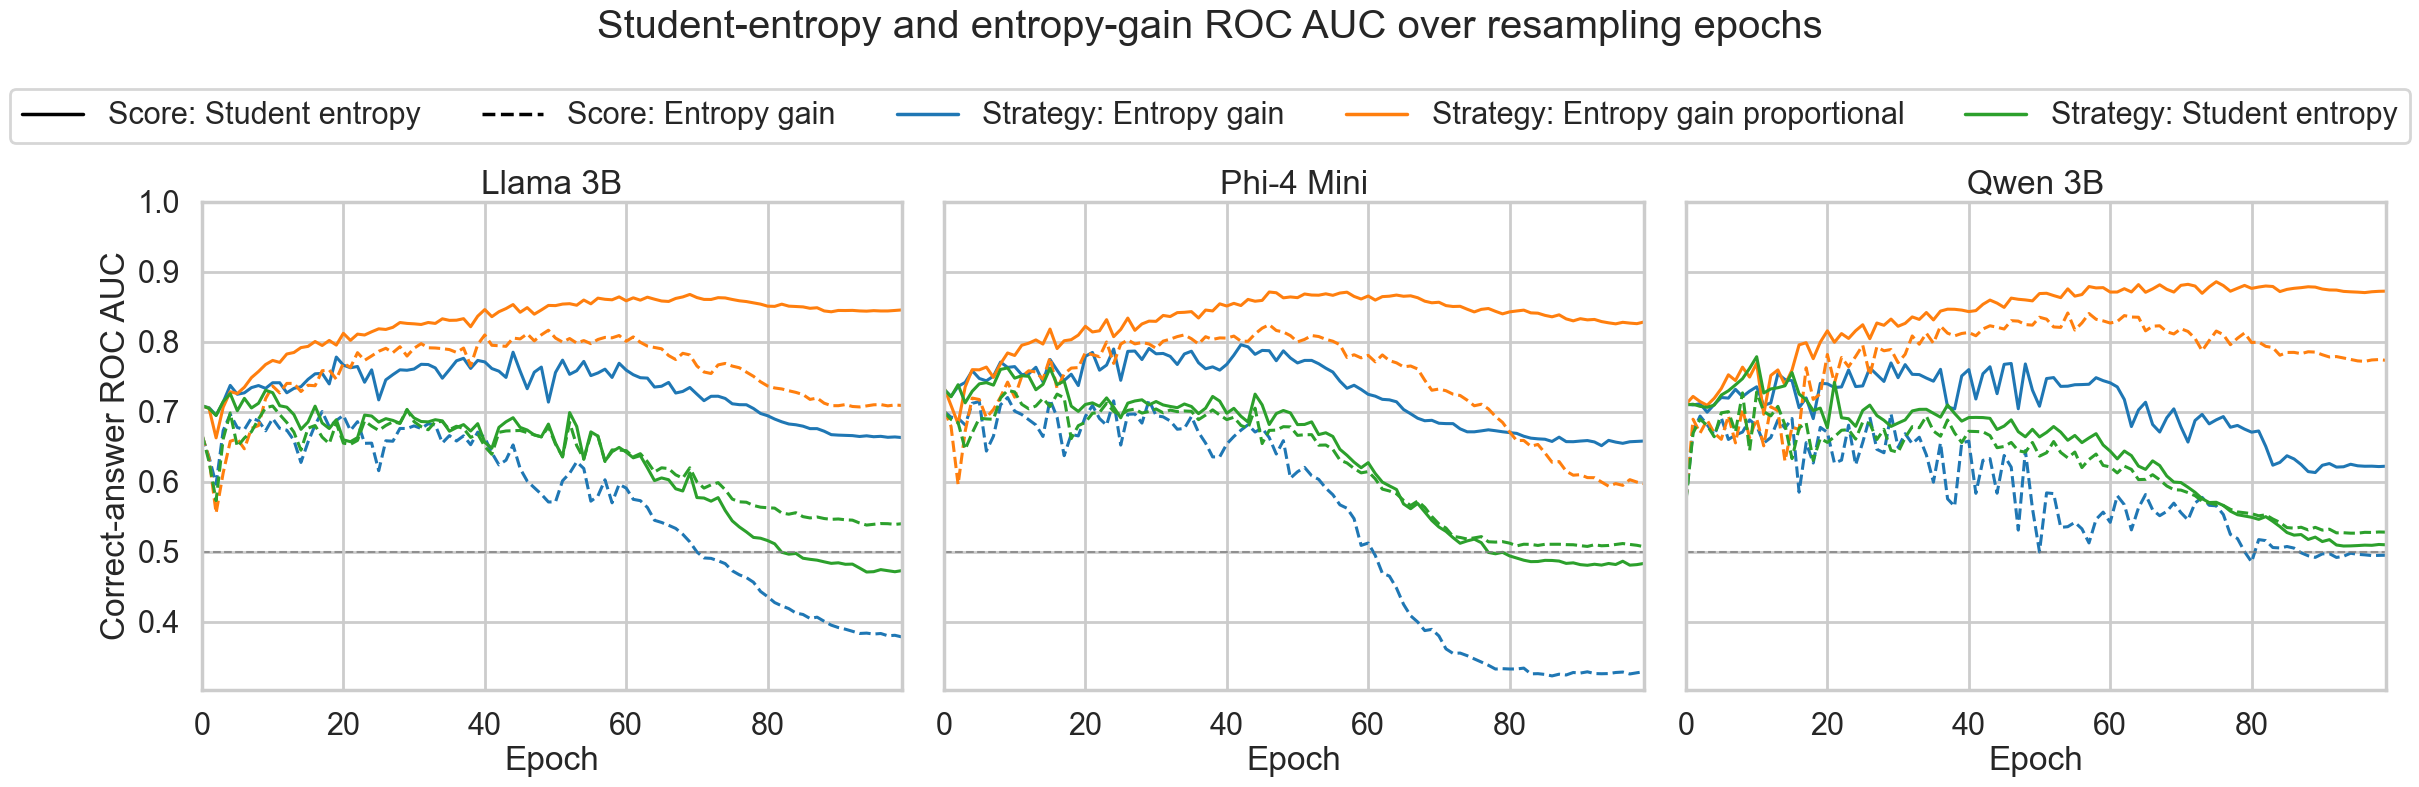

In [7]:
fig, axes = plt.subplots(1, len(models), figsize=(24, 8), sharex=True, sharey=True)

for ax, model in zip(axes, models, strict=True):
    model_data = roc_auc_by_epoch[roc_auc_by_epoch["model"] == model]
    for experiment in EXPERIMENTS:
        curve = model_data[model_data["experiment"] == experiment]
        for score_column, (_, linestyle) in SCORE_LINESTYLES.items():
            ax.plot(
                curve["epoch"],
                curve[score_column],
                color=STRATEGY_COLORS[experiment],
                linestyle=linestyle,
                linewidth=2.2,
            )
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=1.5, alpha=0.8)
    ax.set_title(MODEL_LABELS[model])
    ax.set_xlabel("Epoch")
    ax.set_xlim(min(EXPECTED_EPOCHS), max(EXPECTED_EPOCHS))

axes[0].set_ylabel("Correct-answer ROC AUC")
all_auc_values = roc_auc_by_epoch[["roc_auc", "entropy_gain_roc_auc"]]
axes[0].set_ylim(min(0.48, all_auc_values.min().min() - 0.02), 1.0)
score_handles = [
    Line2D(
        [0], [0], color="black", linestyle=linestyle, linewidth=2.5,
        label=f"Score: {label}",
    )
    for label, linestyle in SCORE_LINESTYLES.values()
]
strategy_handles = [
    Line2D(
        [0], [0], color=STRATEGY_COLORS[experiment], linestyle="-",
        linewidth=2.5, label=f"Strategy: {EXPERIMENT_LABELS[experiment]}",
    )
    for experiment in EXPERIMENTS
]
fig.legend(
    handles=score_handles + strategy_handles, loc="upper center", ncol=5,
    bbox_to_anchor=(0.5, 0.91),
)
fig.suptitle("Student-entropy and entropy-gain ROC AUC over resampling epochs", y=0.99)
fig.subplots_adjust(left=0.08, right=0.99, bottom=0.14, top=0.75, wspace=0.06)

assert sum(len(ax.lines) - 1 for ax in axes) == 18  # exclude each subplot's chance baseline
plt.show()

## ROC AUC within top-complexity subsets

The following figures restrict each epoch to exactly the top 1,024 or top 2,048 rows. `student_entropy` runs are ranked by student entropy; both entropy-gain runs are ranked by clipped entropy gain. The proportional sampler's stochastic race key and the experiment's separate 256-row single-token mix are not included. ROC AUC is then recomputed within each restricted subset for both scores.

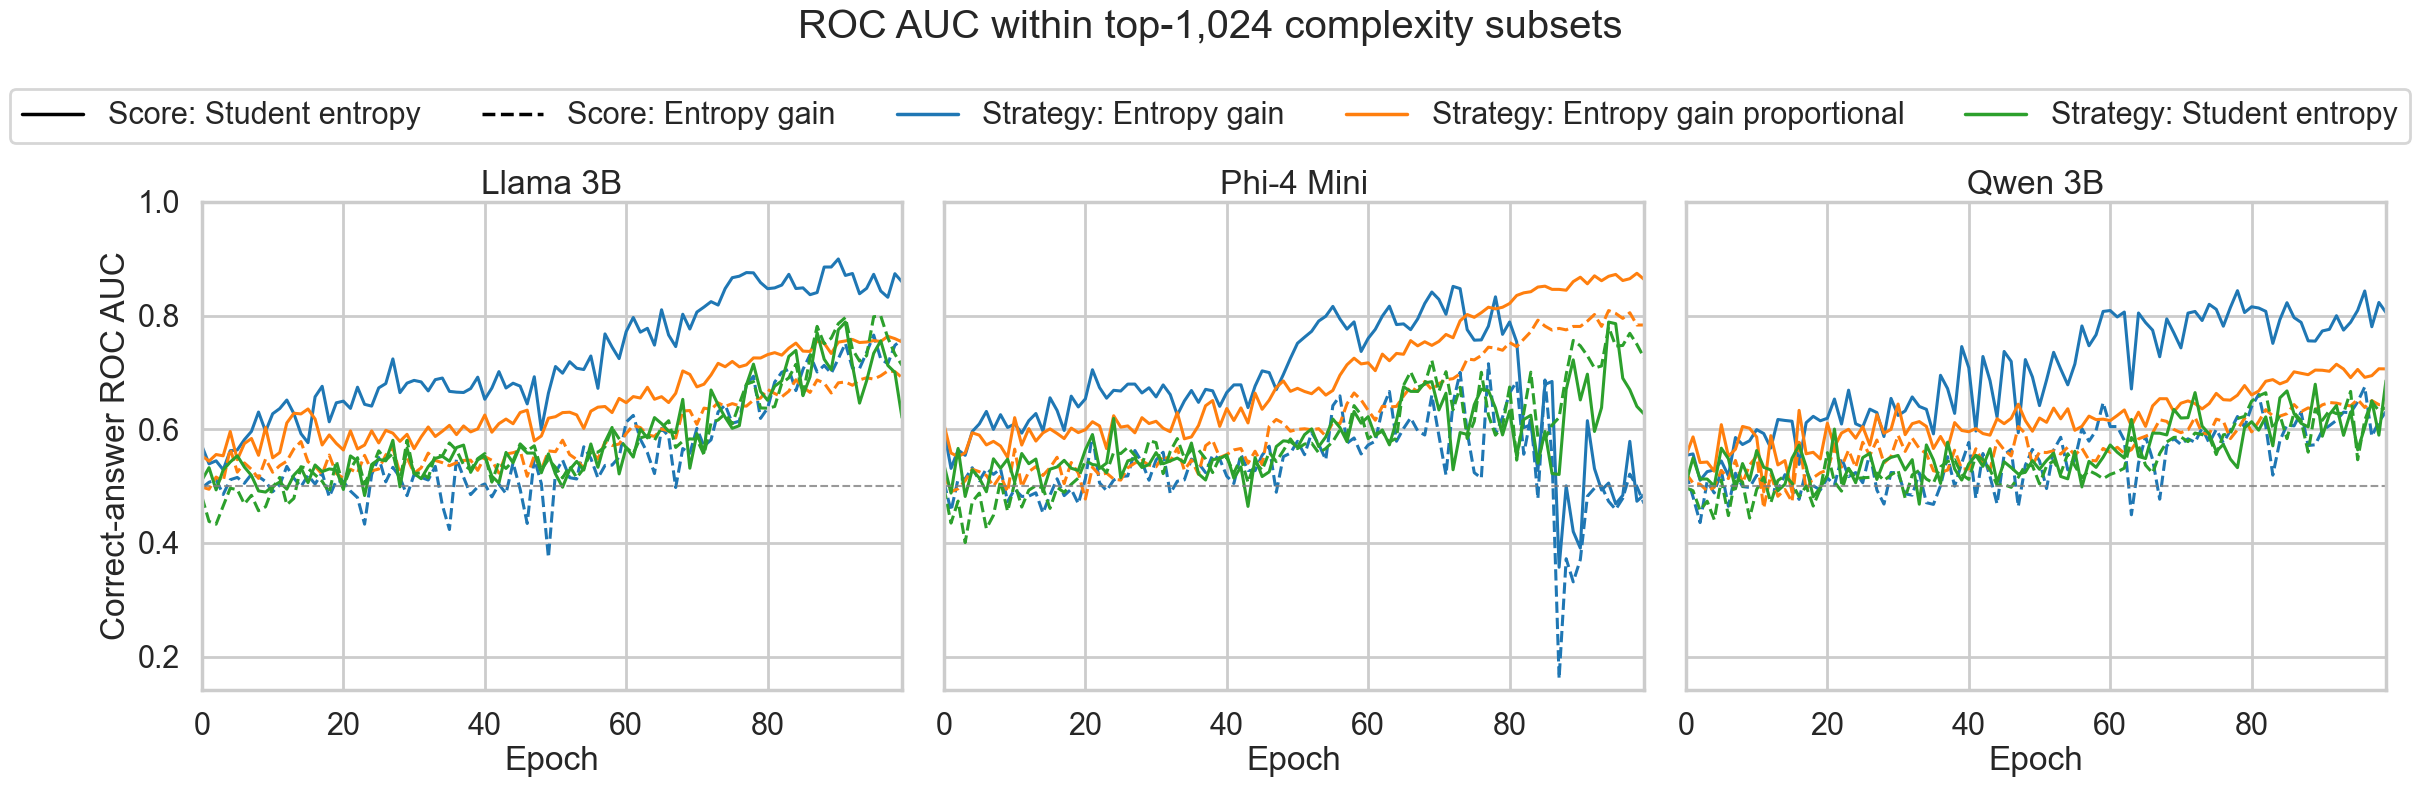

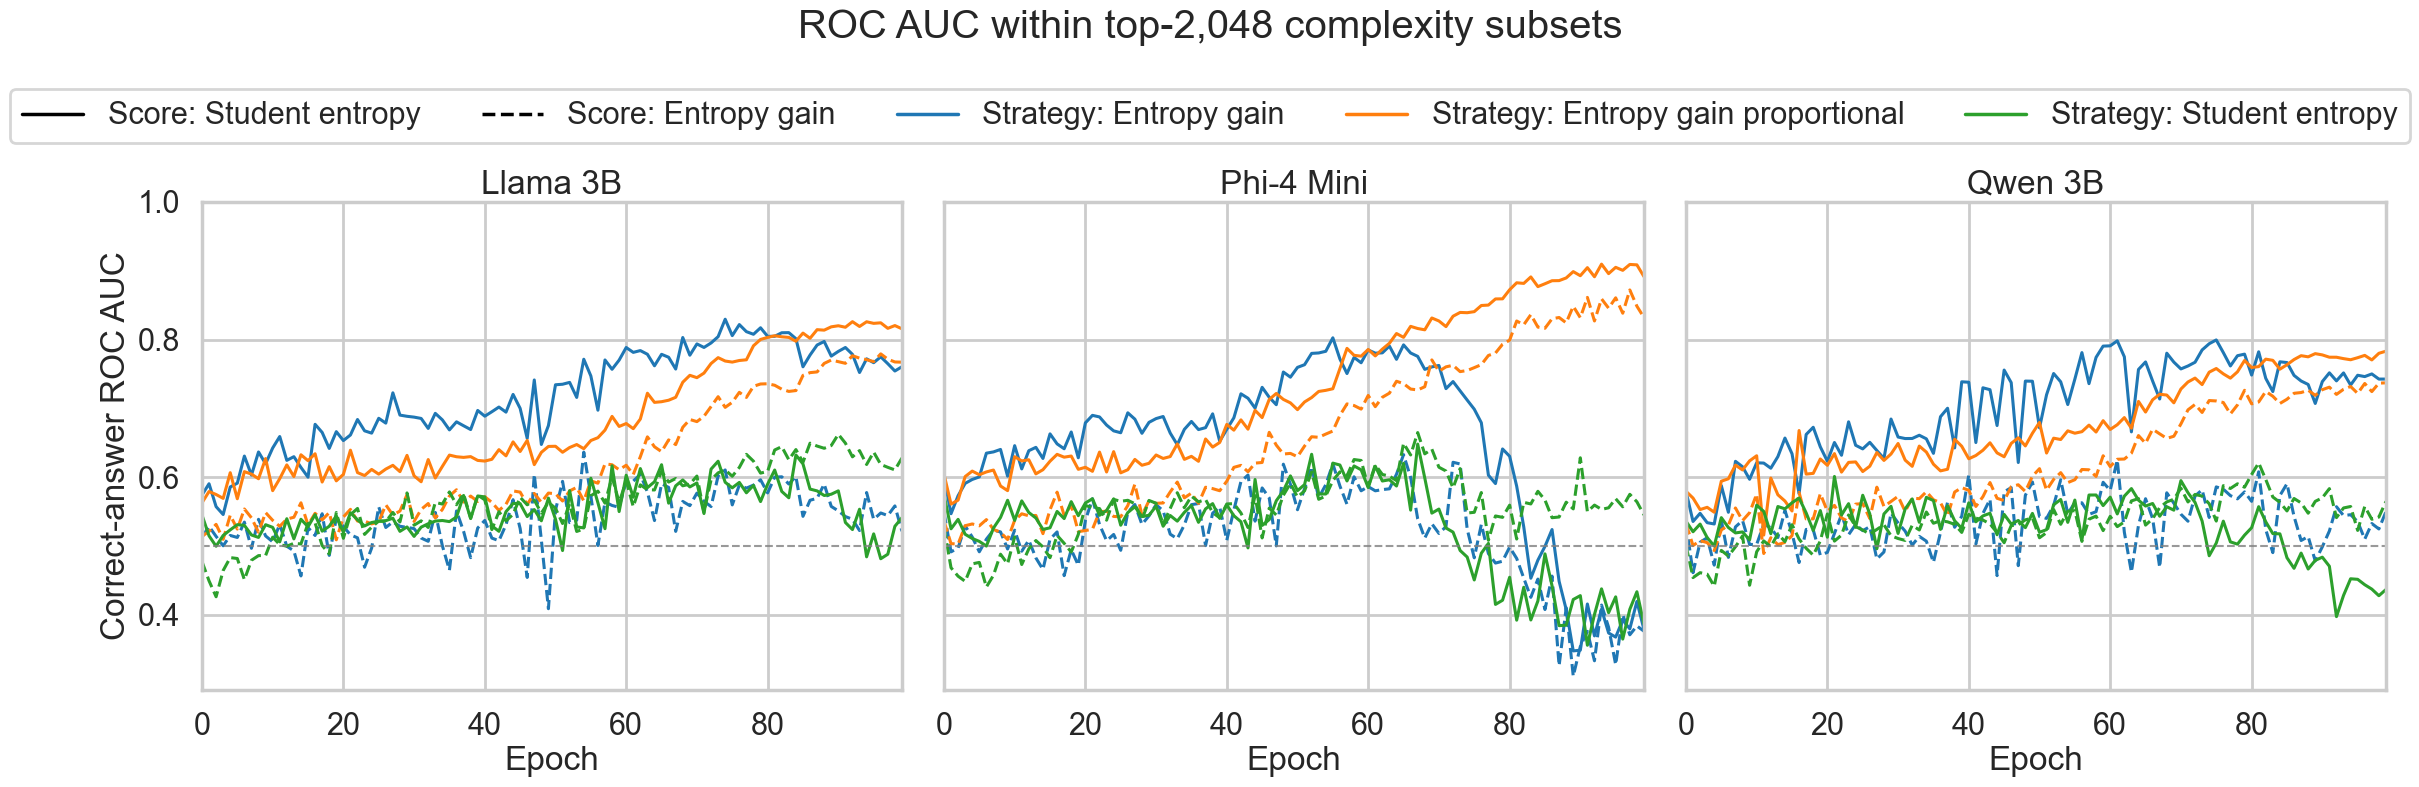

In [8]:
for subset_size in TOP_K_SUBSETS:
    subset_data = subset_roc_auc_by_epoch[
        subset_roc_auc_by_epoch["subset_size"] == subset_size
    ]
    fig, axes = plt.subplots(1, len(models), figsize=(24, 8), sharex=True, sharey=True)

    for ax, model in zip(axes, models, strict=True):
        model_data = subset_data[subset_data["model"] == model]
        for experiment in EXPERIMENTS:
            curve = model_data[model_data["experiment"] == experiment]
            for score_column, (_, linestyle) in SCORE_LINESTYLES.items():
                ax.plot(
                    curve["epoch"],
                    curve[score_column],
                    color=STRATEGY_COLORS[experiment],
                    linestyle=linestyle,
                    linewidth=2.2,
                )
        ax.axhline(0.5, color="gray", linestyle="--", linewidth=1.5, alpha=0.8)
        ax.set_title(MODEL_LABELS[model])
        ax.set_xlabel("Epoch")
        ax.set_xlim(min(EXPECTED_EPOCHS), max(EXPECTED_EPOCHS))

    axes[0].set_ylabel("Correct-answer ROC AUC")
    subset_auc_values = subset_data[["roc_auc", "entropy_gain_roc_auc"]]
    axes[0].set_ylim(min(0.48, subset_auc_values.min().min() - 0.02), 1.0)
    fig.legend(
        handles=score_handles + strategy_handles, loc="upper center", ncol=5,
        bbox_to_anchor=(0.5, 0.91),
    )
    fig.suptitle(
        f"ROC AUC within top-{subset_size:,} complexity subsets", y=0.99
    )
    fig.subplots_adjust(left=0.08, right=0.99, bottom=0.14, top=0.75, wspace=0.06)

    assert sum(len(ax.lines) - 1 for ax in axes) == 18
    plt.show()